# Solution 5A: Sort-Based Portfolios
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

preds = pd.read_parquet("expanding_predictions.parquet")
print(f"Predictions: {len(preds):,} stock-months, {preds['month'].min()} to {preds['month'].max()}")

preds["u"] = preds.groupby("month")["pred"].transform(lambda x: x.rank(pct=True))

Predictions: 66,121 stock-months, 2024-01 to 2025-11


In [2]:
preds["decile"] = preds.groupby("month")["pred"].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates="drop") + 1)
preds["quintile"] = preds.groupby("month")["pred"].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") + 1)

## 1-3. Portfolio returns

In [3]:
d10 = preds[preds["decile"] == preds["decile"].max()].groupby("month")["return"].mean().sort_index()
d1 = preds[preds["decile"] == preds["decile"].min()].groupby("month")["return"].mean().sort_index()
common = sorted(set(d10.index) & set(d1.index))
ls = d10.loc[common] - d1.loc[common]
q5 = preds[preds["quintile"] == preds["quintile"].max()].groupby("month")["return"].mean().sort_index()

## 4. Summary statistics

In [4]:
def stats(r, name):
    sr = r.mean() / r.std() * np.sqrt(12) if r.std() > 0 else 0
    cum = (1 + r).cumprod()
    dd = ((cum - cum.cummax()) / cum.cummax()).min()
    return name, r.mean(), r.std() * np.sqrt(12), sr, dd

print(f"{'Portfolio':30s} {'Mean Mo':>10s} {'Ann Vol':>10s} {'Sharpe':>10s} {'Max DD':>10s}")
print("-" * 72)
for name, mean, vol, sr, dd in [stats(d10, "Top Decile"), stats(q5, "Top Quintile"), stats(ls, "D10-D1 L/S")]:
    print(f"{name:30s} {mean:10.4f} {vol:10.4f} {sr:10.3f} {dd:10.2%}")

Portfolio                         Mean Mo    Ann Vol     Sharpe     Max DD
------------------------------------------------------------------------
Top Decile                         0.0150     0.1922      0.935    -13.12%
Top Quintile                       0.0127     0.1693      0.903    -13.66%
D10-D1 L/S                         0.0497     0.2193      2.723    -11.34%


## 5. Cumulative returns

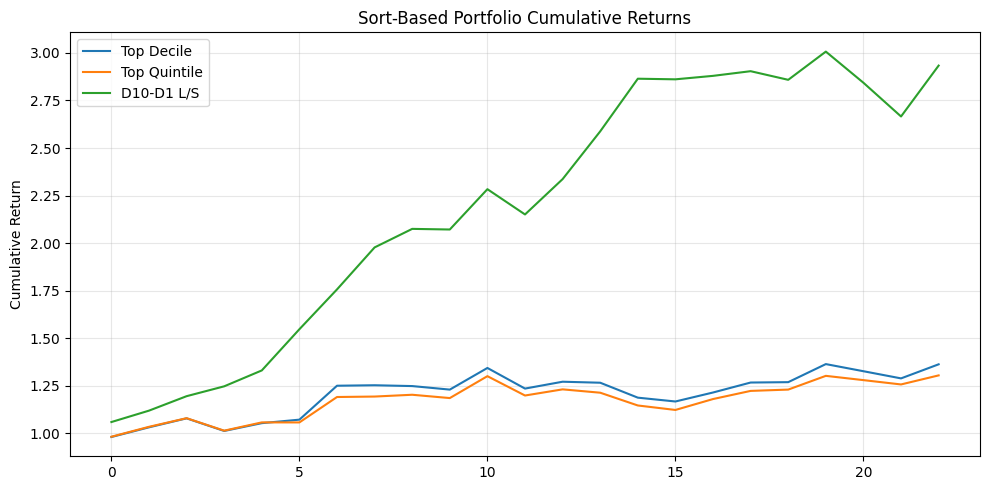

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for r, label in [(d10, "Top Decile"), (q5, "Top Quintile"), (ls, "D10-D1 L/S")]:
    ax.plot(range(len(r)), (1 + r).cumprod().values, label=label)
ax.set_title("Sort-Based Portfolio Cumulative Returns")
ax.set_ylabel("Cumulative Return")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()